In [1]:
!pip install git+https://github.com/KrishnaswamyLab/omics_toolbox.git

  Cloning https://github.com/KrishnaswamyLab/omics_toolbox.git to /tmp/pip-req-build-4i1qpjz8
  Running command git clone --filter=blob:none --quiet https://github.com/KrishnaswamyLab/omics_toolbox.git /tmp/pip-req-build-4i1qpjz8
  Resolved https://github.com/KrishnaswamyLab/omics_toolbox.git to commit 428a79a3be1f6ed440809f8ee022af50e6515cc1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Introduction

In this tutorial, we demonstrate how to use PHATE (Potential of Heat-diffusion for Affinity-based Transition Embedding) to analyze a 31,000 cell 27-day time course of embryoid body (EB) differentiation. You can run and edit this notebook at https://colab.research.google.com/github/KrishnaswamyLab/PHATE/blob/master/Python/tutorial/EmbryoidBody.ipynb. Running the tutorial should take approximately 15 minutes.

We review the following steps:

[1. Loading 10X data](#loading)  
[2. Preprocessing: Filtering, Normalizing, and Transforming](#preprocessing)  
[3. Embedding Data Using PHATE](#embedding)  


## 0. Installation

Run the cell above to install `omics_toolbox`, which bundles all required dependencies (`phate`, `scanpy`, etc.).

## 1. Import libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import scanpy as sc
import phate


# 2. Loading 10x Data

### Downloading Data from Mendeley Datasets

The EB dataset is publically available as `scRNAseq.zip` at Mendelay Datasets at <https://data.mendeley.com/datasets/v6n743h5ng/>.

Inside the scRNAseq folder, there are five subdirectories, and in each subdirectory are three files: `barcodes.tsv`, `genes.tsv`, and `matrix.mtx`. For more information about how CellRanger produces these files, check out the [Gene-Barcode Matrices Documentation](https://support.10xgenomics.com/single-cell-gene-expression/software/pipelines/latest/output/matrices).

Here's the directory structure:
```
download_path
└── scRNAseq
    ├── scRNAseq.zip
    ├── T0_1A
    │   ├── barcodes.tsv
    │   ├── genes.tsv
    │   └── matrix.mtx
    ├── T2_3B
    │   ├── barcodes.tsv
    │   ├── genes.tsv
    │   └── matrix.mtx
    ├── T4_5C
    │   ├── barcodes.tsv
    │   ├── genes.tsv
    │   └── matrix.mtx
    ├── T6_7D
    │   ├── barcodes.tsv
    │   ├── genes.tsv
    │   └── matrix.mtx
    └── T8_9E
        ├── barcodes.tsv
        ├── genes.tsv
        └── matrix.mtx
```

If you have downloaded the files already, set the `download_path` below to the directory where you saved the files. If not, the following code will download the data for you. Not that the download is 746MB: you must have sufficient disk space for the download.

In [3]:
import omics_toolbox as ot

data_path = ot.download_embryoid_body(download_path='data/raw')  # downloads to ~/scRNAseq by default

Trying https://data.mendeley.com/public-files/datasets/v6n743h5ng/files/b1865840-e8df-4381-8866-b04d57309e1d/file_downloaded ...


Downloading:   0%|          | 0.00/162M [00:00<?, ?B/s]

Downloaded to data/raw/scRNAseq.zip
Extracting scRNAseq.zip...
Moving contents to destination directory...
Cleaned up temporary files.

Done! scRNAseq data is in: data/raw/scRNAseq


Scanpy's `read_10x_mtx` reads the standard 10X CellRanger output format:
- `matrix.mtx` (expression matrix)
- `genes.tsv` (gene names)
- `barcodes.tsv` (cell barcodes)

In [6]:
# If data is already downloaded, set data_path manually:
# data_path = os.path.expanduser("~/scRNAseq")
import sys

samples = ['T0_1A', 'T2_3B', 'T4_5C', 'T6_7D', 'T8_9E']
labels = ['Day 00-03', 'Day 06-09', 'Day 12-15', 'Day 18-21', 'Day 24-27']


adatas = []
for sample, label in zip(samples, labels):
    des = os.path.join(data_path, sample)
    adata = sc.read_10x_mtx(des, var_names='gene_symbols', make_unique=True, cache=True)
    adata.obs['timepoint'] = label
    adatas.append(adata)

# Concatenate all samples
adata = sc.concat(adatas, merge="same")
adata.obs_names_make_unique()
print(f"Loaded {adata.n_obs} cells and {adata.n_vars} genes")

data/raw/scRNAseq/T0_1A


SystemExit: 0

## 3. Filtering

### 3.1. Quality control metrics
Quality Control from scanpy's [documentation](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html):

_The scanpy function calculate_qc_metrics() calculates common quality control (QC) metrics, which are largely based on calculateQCMetrics from scater [McCarthy et al., 2017]. One can pass specific gene population to calculate_qc_metrics() in order to calculate proportions of counts for these populations._

In [ ]:
# Calculate QC metrics
## Here we are also computing quality control specific for Mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

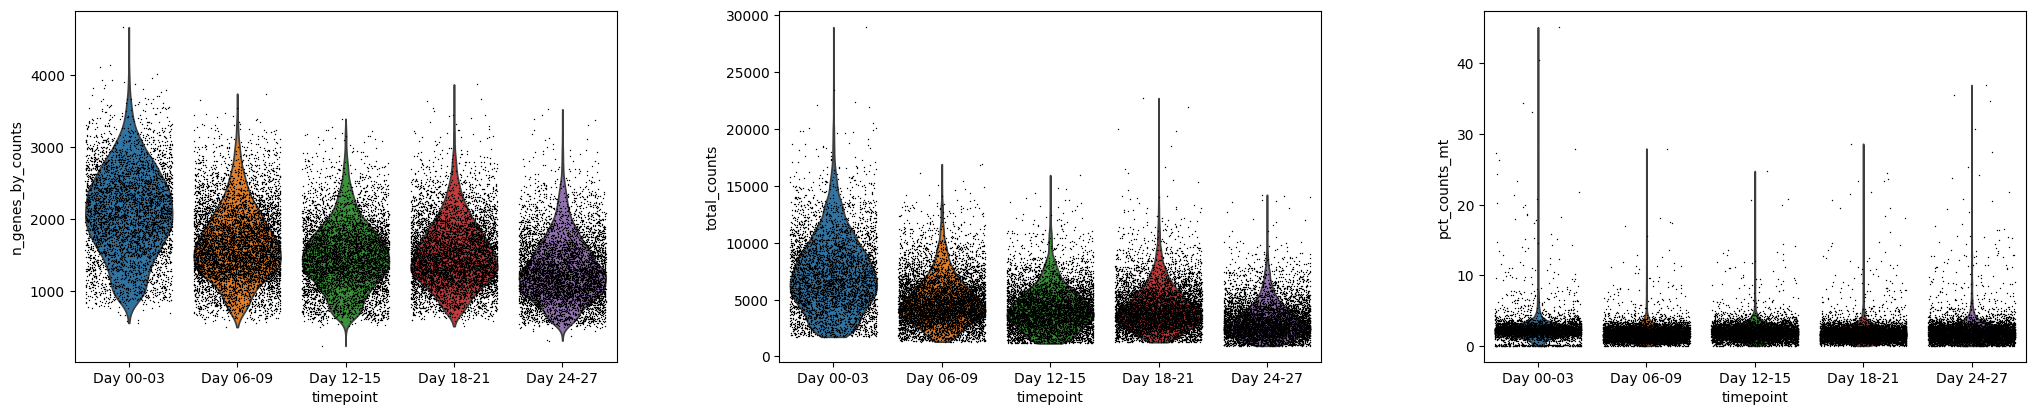

In [ ]:
# Visualize QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='timepoint')

### 3.2 Library Size Filtering
We filter out cells that have either very large or very small library sizes. For this data set, library size correlates somewhat with sample (see the violin plots above) and so we filter on a per-sample basis.

In this case, we eliminate the top and bottom 20% of cells for each sample. Similar results are obtained with simpler, less conservative filtering.

First, let's plot to observe the distribution

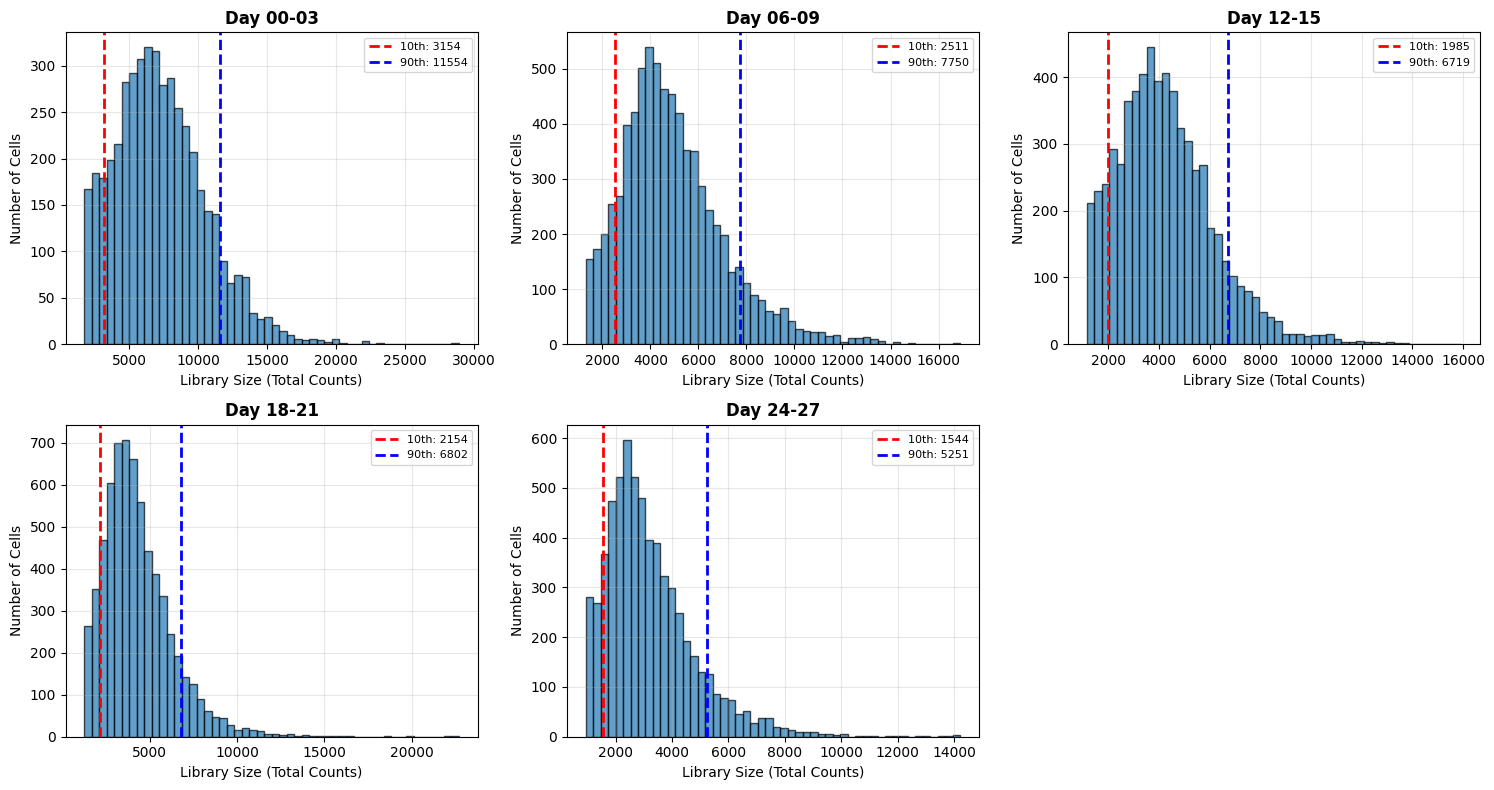

In [ ]:
#Let's set a percentile to filter
min_percentile = 10 # Filter cells lower than the 10th percentile
max_percentile = 90 # Filter cells higher than the 90th percentile

# Create a plot for each sample
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (sample, label) in enumerate(zip(samples, labels)):
    # Filter data for this sample
    sample_mask = adata.obs['timepoint'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    # Calculate thresholds for this sample
    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    # Plot
    axes[idx].hist(sample_counts, bins=50, alpha=0.7, edgecolor='black', log=False)
    axes[idx].axvline(threshold_min, color='red', linestyle='--', linewidth=2,
               label=f'{min_percentile}th: {threshold_min:.0f}')
    axes[idx].axvline(threshold_max, color='blue', linestyle='--', linewidth=2,
               label=f'{max_percentile}th: {threshold_max:.0f}')
    axes[idx].set_xlabel('Library Size (Total Counts)', fontsize=10)
    axes[idx].set_ylabel('Number of Cells', fontsize=10)
    axes[idx].set_title(f'{label}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

# Hide the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Filter cells per sample based on library size percentiles
cells_to_keep = []

for sample, label in zip(samples, labels):
    # Get cells for this sample
    sample_mask = adata.obs['timepoint'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    # Calculate thresholds for this sample
    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    # Identify cells to keep for this sample
    keep_mask = (sample_counts >= threshold_min) & (sample_counts <= threshold_max)
    cells_to_keep.extend(sample_counts[keep_mask].index.tolist())

    print(f"{label}: keeping {keep_mask.sum()}/{len(sample_counts)} cells "
          f"(range: {threshold_min:.0f} - {threshold_max:.0f})")

# Filter the AnnData object
adata = adata[cells_to_keep, :].copy()
print(f"\nTotal cells after filtering: {adata.n_obs}")

Day 00-03: keeping 3719/4649 cells (range: 3154 - 11554)
Day 06-09: keeping 5903/7377 cells (range: 2511 - 7750)
Day 12-15: keeping 4995/6245 cells (range: 1985 - 6719)
Day 18-21: keeping 5250/6563 cells (range: 2154 - 6802)
Day 24-27: keeping 5061/6327 cells (range: 1544 - 5251)

Total cells after filtering: 24928


### 3.3 Removing rare genes
Let's eliminate genes that are expressed in 10 cells or fewer.

In [ ]:
# Eliminate genes that are expressed in few cells
min_cells = 10
sc.pp.filter_genes(adata, min_cells=min_cells)

### 3.4. Normalization
To correct for differences in library sizes, we divide each cell by its library size and then rescale by the median library size.

In [ ]:
# Normalize to median library size
sc.pp.normalize_total(adata, target_sum=np.median(adata.obs['total_counts']))

### 3.5. Dead cell removal
Dead cells are likely to have a higher mitochondrial RNA expression level than live cells. Therefore, we remove suspected dead cells by eliminating cells that have the highest mitochondrial RNA expression levels on average.  

First let's look at the distribution of mitochontrial genes.

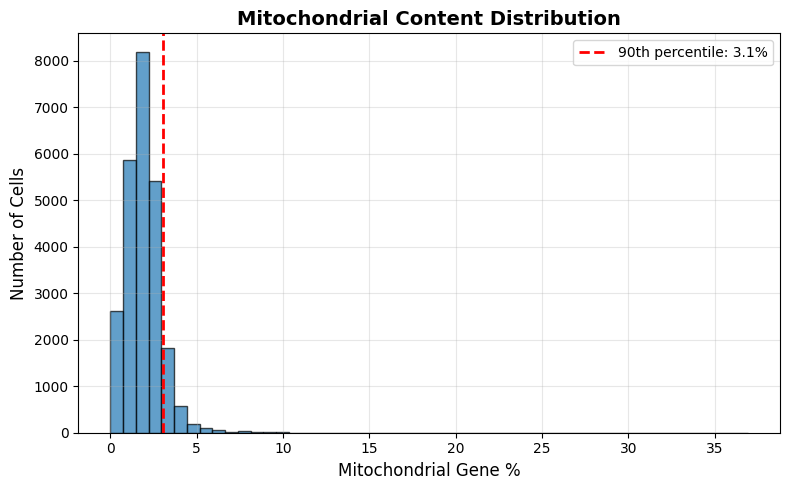

In [ ]:
# Get mitochondrial percentages
mito_pct = adata.obs['pct_counts_mt']
mito_percentile = 90
mito_threshold = np.percentile(mito_pct, mito_percentile)  # Upper percentile

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mito_pct, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(mito_threshold, color='red', linestyle='--', linewidth=2,
           label=f'{mito_percentile}th percentile: {mito_threshold:.1f}%')
ax.set_xlabel('Mitochondrial Gene %', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title('Mitochondrial Content Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Filter cells with high mitochondrial content
adata = adata[adata.obs['pct_counts_mt'] < mito_threshold].copy()

### 3.5. Transformation

In scRNA-seq analysis, the data is often $\log$-transformed. This typically requires the addition of some small value to avoid taking $\log(0)$. We avoid this issue entirely by instead taking the square root transform. The square root function has a similar form as the $\log$ function with the added benefit of being stable at 0.

In [ ]:
# Square root transform (alternative to log transform, stable at zero)
# sc.pp.log1p(adata)  # You can also use log1p if preferred
adata.X = np.sqrt(adata.X) # We use

## 4. Embedding Data Using PHATE

### 4.1 Instantiating the PHATE estimator

The API of PHATE models that of Scikit Learn. First, you instantiate a PHATE estimator object with the parameters for fitting the PHATE embedding to a given dataset. Next, you use the `fit` and `fit_transform` functions to generate an embedding. For more information, check out [**the PHATE readthedocs page**](http://phate.readthedocs.io/).

We'll just use the default parameters for now, but the following parameters can be tuned (read our documentation at [phate.readthedocs.io](https://phate.readthedocs.io/) to learn more):

* `knn` : Number of nearest neighbors (default: 5). Increase this (e.g. to 20) if your PHATE embedding appears very disconnected. You should also consider increasing `knn` if your dataset is extremely large (e.g. >100k cells)
* `decay` : Alpha decay (default: 15). Decreasing `decay` increases connectivity on the graph, increasing `decay` decreases connectivity. This rarely needs to be tuned. Set it to `None` for a k-nearest neighbors kernel.
* `t` : Number of times to power the operator (default: 'auto'). This is equivalent to the amount of smoothing done to the data. It is chosen automatically by default, but you can increase it if your embedding lacks structure, or decrease it if the structure looks too compact.
* `gamma` : Informational distance constant (default: 1). `gamma=1` gives the PHATE log potential, but other informational distances can be interesting. If most of the points seem concentrated in one section of the plot, you can try `gamma=0`.

In [ ]:
# Run PHATE
phate_operator = phate.PHATE(knn=5, decay=15, n_jobs=-2, verbose=True)
adata.obsm['X_phate'] = phate_operator.fit_transform(adata.X)

Calculating PHATE...
  Running PHATE on 22435 observations and 18507 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 7.80 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.37 seconds.
    Calculating affinities...
    Calculated affinities in 2.47 seconds.
  Calculated graph and diffusion operator in 10.78 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 2.61 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.87 seconds.
  Calculated landmark operator in 5.48 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 0.93 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.24 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.30 seconds.
Calculated PHATE in 19.37 seconds.


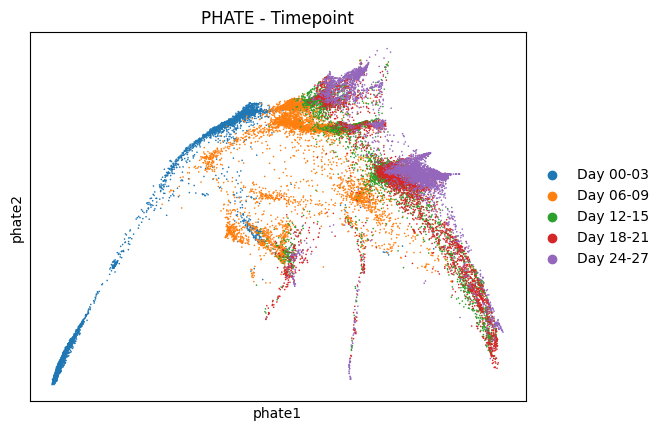

In [ ]:
# Visualize PHATE colored by timepoint
sc.pl.embedding(adata, basis='phate', color='timepoint', cmap="Spectral",title='PHATE - Timepoint')

Since we are looking for subtle structure and we expect some of the trajectories to be sparse, we might want to decrease `knn` from the default of 5, and reduce `t` from the automatic value of 21 (printed in the output above). For single-cell RNA-seq you can try `knn` as low as 3 or 4 if you're looking for subtle structure, or as high as 30 or 40 if you have hundreds of thousands of cells. We'll also reduce `alpha` here to 15 to partially offset the decreased connectivity as a result of decreasing `knn`.

In [ ]:
phate_operator.set_params(knn=4, decay=15, t=12)
# We could also create a new operator:
# phate_operator = phate.PHATE(knn=4, decay=15, t=12, n_jobs=-2)

Y_phate = phate_operator.fit_transform(adata.X)

Calculating PHATE...
  Running PHATE on 22435 observations and 18507 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 7.75 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.27 seconds.
    Calculating affinities...
    Calculated affinities in 1.11 seconds.
  Calculated graph and diffusion operator in 9.22 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 2.07 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.56 seconds.
  Calculated landmark operator in 4.62 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.20 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.25 seconds.
Calculated PHATE in 15.89 seconds.


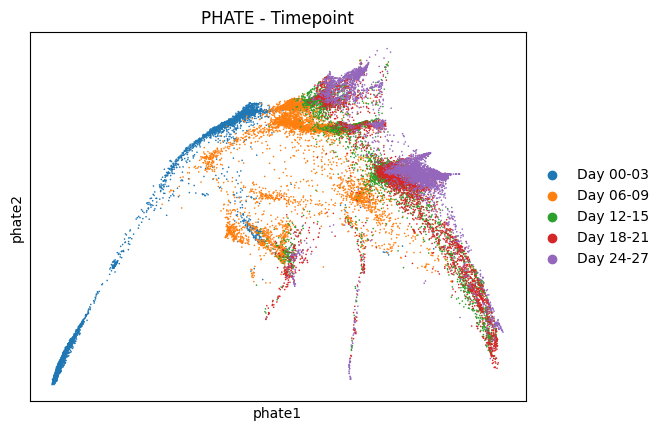

In [ ]:
# Visualize PHATE colored by timepoint
sc.pl.embedding(adata, basis='phate', color='timepoint', cmap="Spectral",title='PHATE - Timepoint')

We can also visualize the embedding in 3D. (using matplotlib)

Calculating metric MDS...
  SGD-MDS may not have converged: stress changed by -2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Calculated metric MDS in 1.52 seconds.


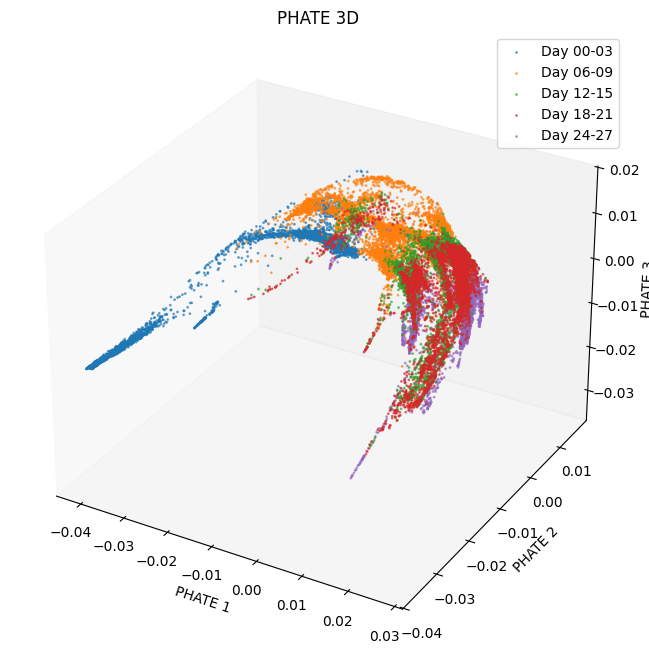

In [ ]:
# 3D PHATE
phate_operator.set_params(n_components=3)
adata.obsm['X_phate_3d'] = phate_operator.transform()

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, batch in enumerate(adata.obs['timepoint'].unique()):
    mask = adata.obs['timepoint'] == batch
    ax.scatter(adata.obsm['X_phate_3d'][mask, 0],
               adata.obsm['X_phate_3d'][mask, 1],
               adata.obsm['X_phate_3d'][mask, 2],
               label=batch, alpha=0.6, s=1)

ax.legend()
ax.grid(False)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_zlabel('PHATE 3')
plt.title('PHATE 3D')
plt.show()

## 8. Visualize gene expression on PHATE

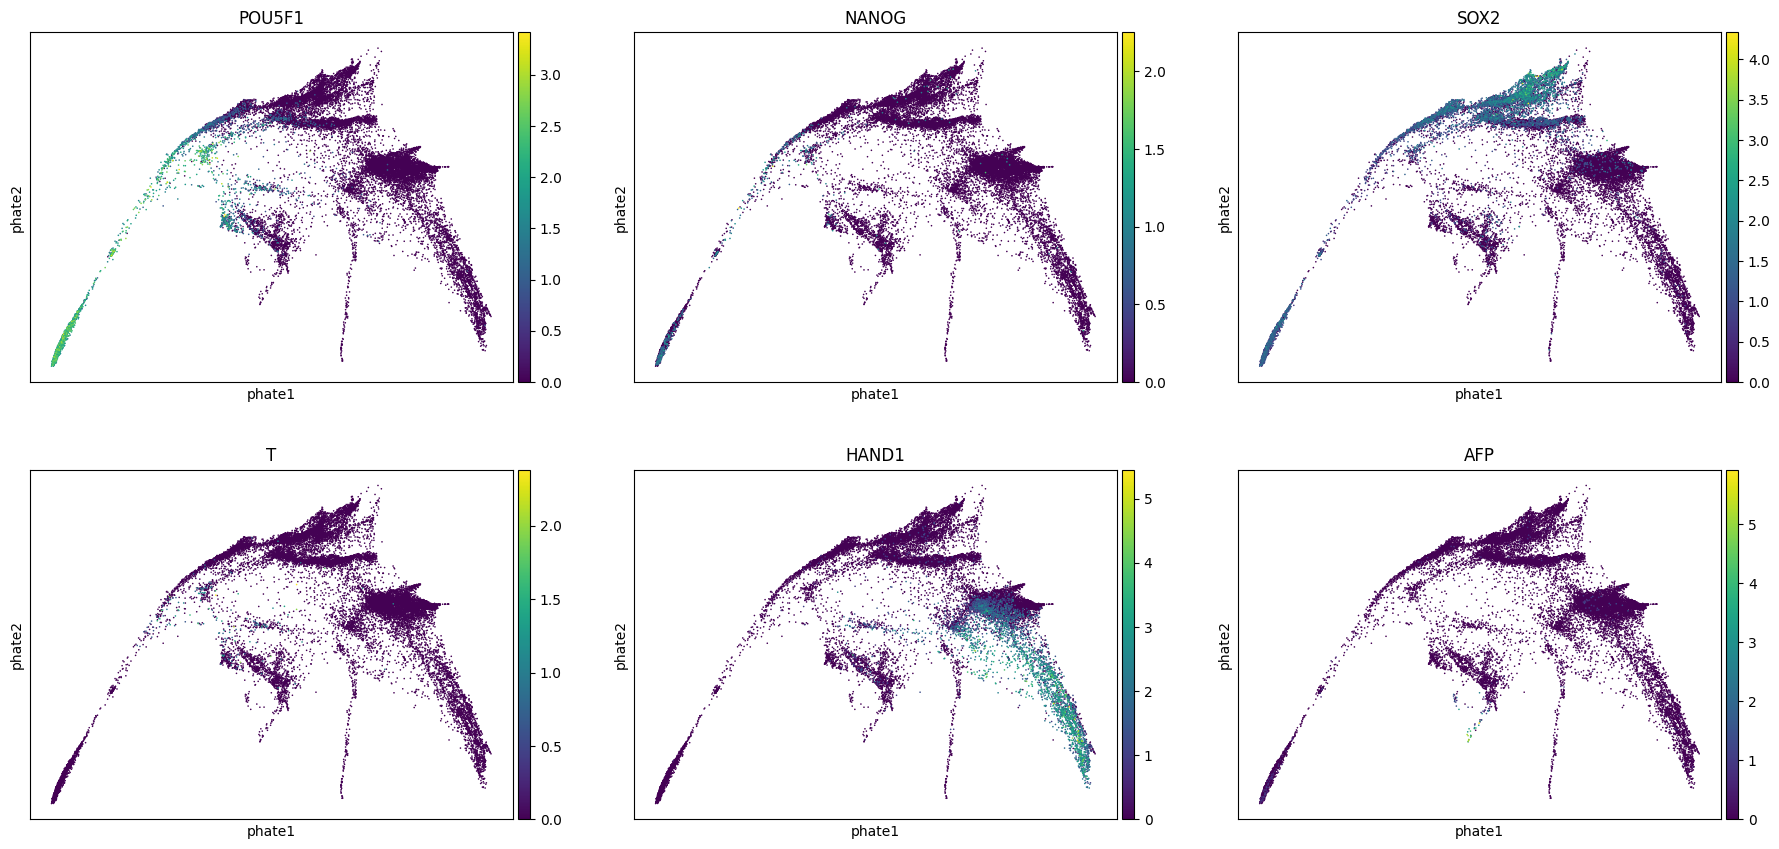

In [ ]:
# Example: visualize marker genes
genes = ['POU5F1', 'NANOG', 'SOX2', 'T', 'HAND1', 'AFP']
sc.pl.embedding(adata, basis='phate', color=genes, cmap='viridis', ncols=3)

## Comparison with other visualization tools

In this section we will compare PHATE to other common visualization tools on this dataset.

* PCA
* t-SNE

Neither of these methods accept sparse input, so this will only work if you have a lot of memory available. Also, we apply PCA before t-SNE, as is common practice.

In [ ]:
import time

# PCA
start = time.time()
sc.tl.pca(adata, n_comps=50)  # Computes PCA and stores in adata.obsm['X_pca']
end = time.time()
print("Embedded PCA in {:.2f} seconds.".format(end-start))

# t-SNE (typically done after PCA for speed)
start = time.time()
sc.tl.tsne(adata, n_pcs=50)  # Uses PCA results, stores in adata.obsm['X_tsne']
end = time.time()
print("Embedded t-SNE in {:.2f} seconds.".format(end-start))

# Access the results
Y_pca = adata.obsm['X_pca'][:, :2]  # First 2 PCA components
Y_tsne = adata.obsm['X_tsne']  # t-SNE embedding (2D)

Embedded PCA in 7.72 seconds.
Embedded t-SNE in 33.89 seconds.


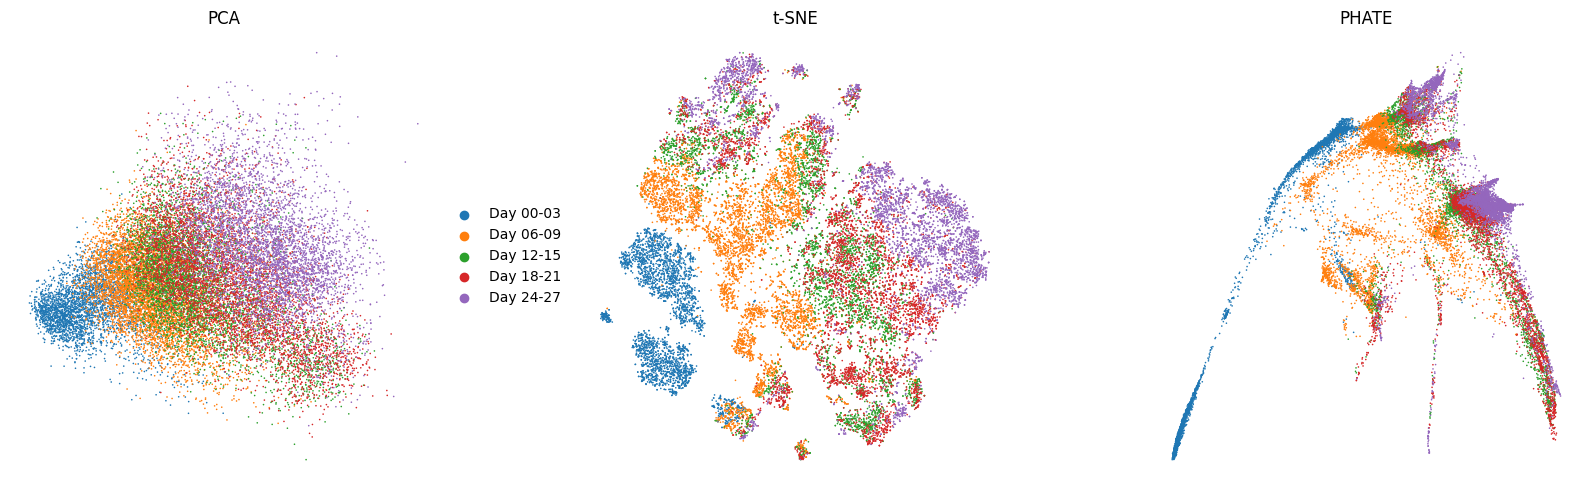

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# plotting PCA
sc.pl.embedding(adata, basis='pca', color='timepoint',
                title="PCA", show=False, ax=ax1,
                frameon=False, colorbar_loc=None)

# plotting t-SNE
sc.pl.embedding(adata, basis='tsne', color='timepoint',
                title="t-SNE", show=False, ax=ax2, legend_loc='none',
                frameon=False, colorbar_loc=None)

# plotting PHATE
sc.pl.embedding(adata, basis='phate', color='timepoint',
                title="PHATE", show=False, ax=ax3, legend_loc='none',
                frameon=False, colorbar_loc=None)

plt.tight_layout()
plt.show()